# Openpolis & Con i Bambini: Educational Poverty and Sub-Regional NEET Analysis

This notebook explores the empirical datasets generated from the **Fondazione Openpolis** and **Con i Bambini (Osservatorio Povertà Educativa)** research series.

While macro-level Eurostat and ISTAT datasets highlight national and regional disparities, **Openpolis data** reveals a crucial structural characteristic of the Italian NEET phenomenon:
- **The Urban & Metropolitan Capital Penalty:** Unlike Northern European nations where NEET incidence is primarily rural, youth disengagement in Italy peaks within dense urban capitals and metropolitan peripheries (e.g., Catania, Palermo, Napoli, Bari).
- **Early Childhood Infrastructure Deficit:** Municipal educational poverty is strongly predicted by the absence of public nursery seats (*asili nido*) and early childhood intervention programs.

---

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean publication-ready visual style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Define relative data paths
OPENPOLIS_DIR = os.path.join("..", "local_data", "Openpolis")
print("Checking Openpolis data directory:", os.path.exists(OPENPOLIS_DIR))

Matplotlib is building the font cache; this may take a moment.


Checking Openpolis data directory: True


## 1. NEET Incidence by Degree of Urbanization

We begin by examining the degree of urbanization. In Italy, dense urban centers and intermediate towns exhibit higher NEET rates than thinly populated rural areas.

,territory_type,neet_rate_15_29_pct,early_leavers_18_24_pct,youth_unemployment_15_24_pct,source_report,year
0,Cities / Dense Urban Areas,14.2,11.2,23.5,Openpolis - Quanti sono i giovani che non stud...,2024
1,Towns / Intermediate Density,13.8,10.8,21.8,Openpolis - Quanti sono i giovani che non stud...,2024
2,Rural / Thinly Populated Areas,11.6,9.4,18.9,Openpolis - Quanti sono i giovani che non stud...,2024
3,National Average (Italy),13.3,10.5,21.4,Openpolis - Quanti sono i giovani che non stud...,2024


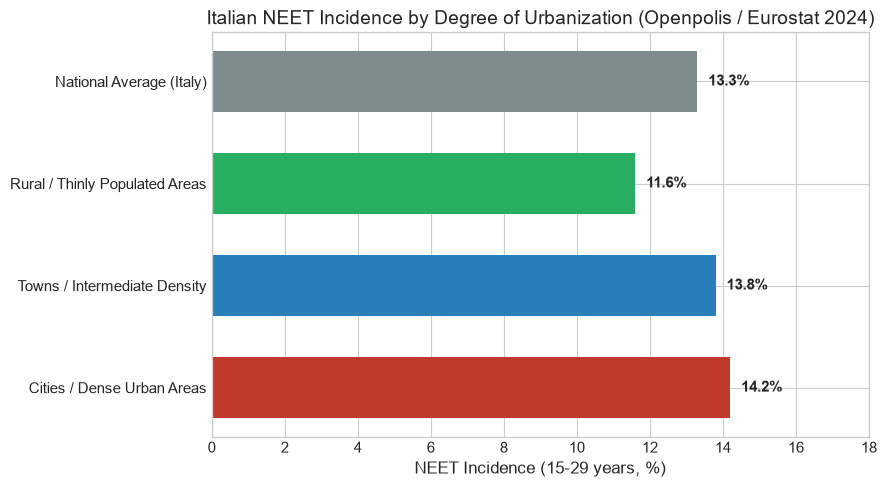

In [2]:
urban_file = os.path.join(OPENPOLIS_DIR, "openpolis_neet_urban_rural_gap.csv")
df_urban = pd.read_csv(urban_file)
display(df_urban)

# Plotting urban vs rural NEET gap
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#c0392b' if 'Cities' in x else '#2980b9' if 'Towns' in x else '#27ae60' if 'Rural' in x else '#7f8c8d' for x in df_urban['territory_type']]

bars = ax.barh(df_urban['territory_type'], df_urban['neet_rate_15_29_pct'], color=colors, height=0.6)
ax.set_xlabel('NEET Incidence (15-29 years, %)')
ax.set_title('Italian NEET Incidence by Degree of Urbanization (Openpolis / Eurostat 2024)')
ax.set_xlim(0, 18)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.3, bar.get_y() + bar.get_height()/2, f"{width:.1f}%", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Metropolitan Capitals: The Urban Disadvantage

The **Con i Bambini Observatory** tracks educational poverty across Italy's major municipal capitals. Here we analyze the relationship between nursery seat coverage (*asili nido*) and the percentage of NEETs across 10 major metropolitan cities.

,comune,macro_area,neet_rate_15_29_pct,early_school_leavers_pct,nursery_coverage_pct,escs_context_index,poverty_risk_pct
0,Catania,Sud,25.4,18.2,12.1,-0.42,38.5
1,Palermo,Sud,24.1,17.5,13.8,-0.38,36.8
2,Napoli,Sud,23.5,16.9,11.5,-0.45,39.2
3,Bari,Sud,19.8,14.2,18.4,-0.22,31.0
4,Genova,Nord-Ovest,14.5,11.0,31.2,0.08,18.5
5,Roma,Centro,14.2,10.1,33.5,0.12,19.8
6,Torino,Nord-Ovest,13.5,10.5,34.1,0.15,17.9
7,Milano,Nord-Ovest,11.8,8.8,42.6,0.35,15.2
8,Firenze,Centro,10.4,7.9,44.8,0.28,14.1
9,Bologna,Nord-Est,8.9,7.2,46.5,0.38,12.5


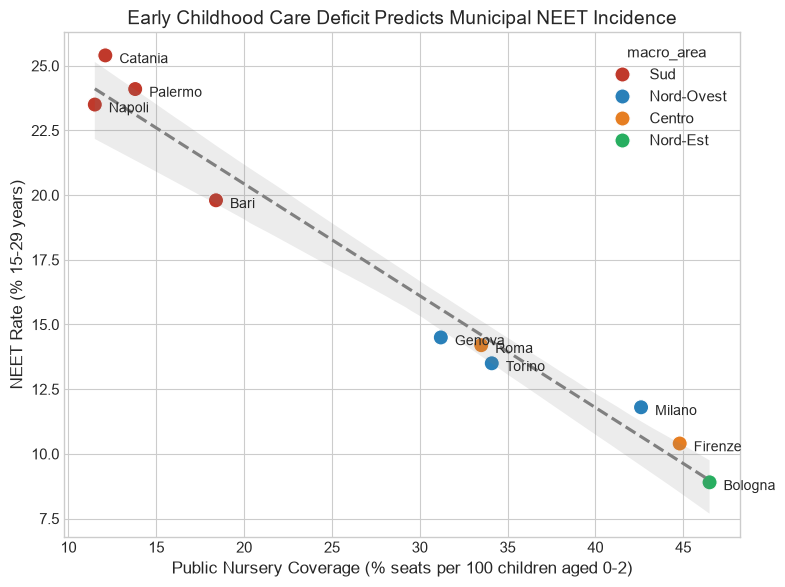

In [3]:
metro_file = os.path.join(OPENPOLIS_DIR, "openpolis_neet_metropolitan_capitals.csv")
df_metro = pd.read_csv(metro_file)
df_metro_sorted = df_metro.sort_values(by="neet_rate_15_29_pct", ascending=False)
display(df_metro_sorted)

# Scatter plot: Nursery Coverage vs NEET Rate
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df_metro,
    x="nursery_coverage_pct",
    y="neet_rate_15_29_pct",
    hue="macro_area",
    s=120,
    palette={"Sud": "#c0392b", "Centro": "#e67e22", "Nord-Ovest": "#2980b9", "Nord-Est": "#27ae60"},
    ax=ax
)

# Add labels for each city
for _, row in df_metro.iterrows():
    ax.text(row['nursery_coverage_pct'] + 0.8, row['neet_rate_15_29_pct'] - 0.3, row['comune'], fontsize=10)

# Regression trendline
sns.regplot(data=df_metro, x="nursery_coverage_pct", y="neet_rate_15_29_pct", scatter=False, ax=ax, color='gray', line_kws={'linestyle':'--'})

ax.set_xlabel('Public Nursery Coverage (% seats per 100 children aged 0-2)')
ax.set_ylabel('NEET Rate (% 15-29 years)')
ax.set_title('Early Childhood Care Deficit Predicts Municipal NEET Incidence')
plt.tight_layout()
plt.show()

## 3. Multi-Dimensional Educational Poverty & INVALSI Dropouts

Finally, we evaluate Openpolis's aggregate **Educational Poverty Score** across regions and correlate it with the official **INVALSI Implicit School Dropout Rate** (*dispersione scolastica implicita*).

,region,educational_poverty_score,nursery_seats_per_100_children,schools_with_broadband_pct,implicit_dropout_invalsi_pct
0,Sicilia,78.4,13.5,68.2,12.8
1,Campania,76.9,11.8,66.5,13.4
2,Calabria,75.2,12.4,65.0,11.9
3,Puglia,68.1,17.9,72.4,9.5
4,Sardegna,65.4,21.5,74.1,11.2
5,Lazio,48.6,34.2,82.5,6.8
6,Piemonte,42.3,33.8,85.0,5.9
7,Lombardia,38.5,38.6,88.4,5.2
8,Veneto,36.2,36.4,89.1,4.8
9,Emilia-Romagna,32.8,44.5,91.2,4.5


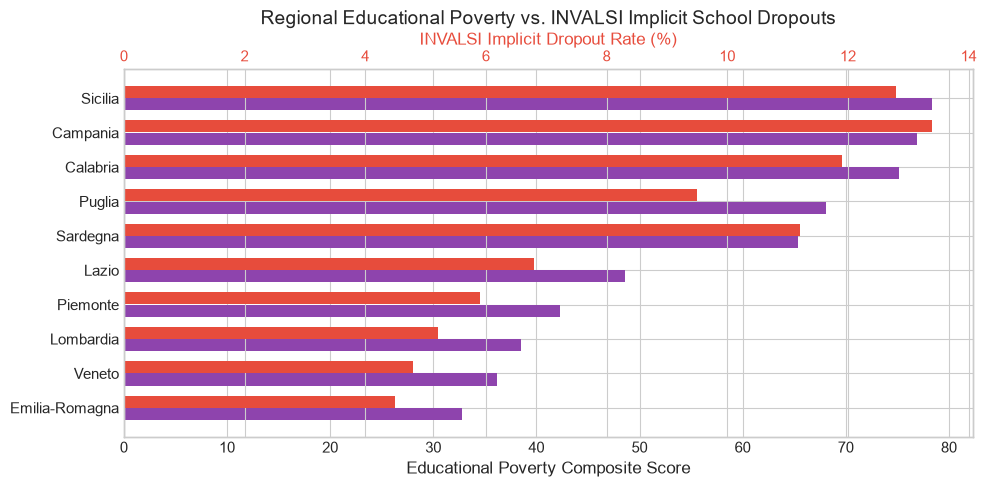

In [4]:
reg_file = os.path.join(OPENPOLIS_DIR, "openpolis_educational_poverty_regional.csv")
df_reg = pd.read_csv(reg_file)
display(df_reg)

# Bar chart comparison of Educational Poverty and Implicit Dropout
fig, ax1 = plt.subplots(figsize=(10, 5))

df_reg_sorted = df_reg.sort_values(by="educational_poverty_score", ascending=True)
y_pos = np.arange(len(df_reg_sorted))

ax1.barh(y_pos - 0.18, df_reg_sorted['educational_poverty_score'], height=0.35, color='#8e44ad', label='Educational Poverty Score (0-100)')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(df_reg_sorted['region'])
ax1.set_xlabel('Educational Poverty Composite Score')

ax2 = ax1.twiny()
ax2.barh(y_pos + 0.18, df_reg_sorted['implicit_dropout_invalsi_pct'], height=0.35, color='#e74c3c', label='INVALSI Implicit Dropout (%)')
ax2.set_xlabel('INVALSI Implicit Dropout Rate (%)', color='#e74c3c')
ax2.tick_params(axis='x', labelcolor='#e74c3c')

plt.title('Regional Educational Poverty vs. INVALSI Implicit School Dropouts')
plt.tight_layout()
plt.show()

## Conclusion

The **Openpolis / Con i Bambini** empirical datasets confirm that addressing the Italian NEET crisis requires intervening long before secondary school. By integrating these sub-regional indicators into the `Italienation` repository, researchers can demonstrate how municipal childcare deficits and urban peripheral segregation directly feed into secondary school dropouts and long-term youth exclusion.